In [6]:
import pandas as pd
from sqlalchemy import create_engine, text

In [22]:
engine = create_engine(
    "postgresql+psycopg2://jakieldavid@localhost:5432/worldMYSQL.sql"
)

In [8]:
connection = engine.connect()

In [ ]:
result = connection.execute(text("SELECT * FROM country LIMIT 5"))

df = pd.DataFrame(result.fetchall(), columns=result.keys())

df

,code,name,continent,region,surfacearea,indepyear,population,lifeexpectancy,gnp,gnpold,localname,governmentform,headofstate,capital,code2
0,ABW,Aruba ...,North America ...,Caribbean,193.00,NaN,103000,78.4,828.00,793.00,Aruba,Nonmetropolitan Territory of The Netherlands,Beatrix ...,129,AW
1,AFG,Afghanistan ...,Asia ...,Southern and Central Asia,652090.00,1919.0,22720000,45.9,5976.00,None,Afganistan/Afqanestan,Islamic Emirate,Mohammad Omar ...,1,AF
2,AGO,Angola ...,Africa ...,Central Africa,1246700.00,1975.0,12878000,38.3,6648.00,7984.00,Angola,Republic,José Eduardo dos Santos ...,56,AO
3,AIA,Anguilla ...,North America ...,Caribbean,96.00,NaN,8000,76.1,63.20,None,Anguilla,Dependent Territory of the UK,Elisabeth II ...,62,AI
4,ALB,Albania ...,Europe ...,Southern Europe,28748.00,1912.0,3401200,71.6,3205.00,2500.00,Shqipëria,Republic,Rexhep Mejdani ...,34,AL


In [ ]:
result = connection.execute(
    text("""
SELECT country.Name,
       COUNT(countrylanguage.Language) AS Number_Official_Languages
FROM country
JOIN countrylanguage
    ON country.Code = countrylanguage.CountryCode
WHERE countrylanguage.isofficial = 'T'
GROUP BY country.Name
HAVING COUNT(countrylanguage.Language) > 2
ORDER BY Number_Official_Languages DESC;
""")
)

In [11]:
df = pd.DataFrame(result.fetchall(), columns=result.keys())
df

,name,number_official_languages
0,Switzerland ...,4
1,South Africa ...,4
2,Vanuatu ...,3
3,Belgium ...,3
4,Luxembourg ...,3
5,Peru ...,3
6,Bolivia ...,3
7,Singapore ...,3


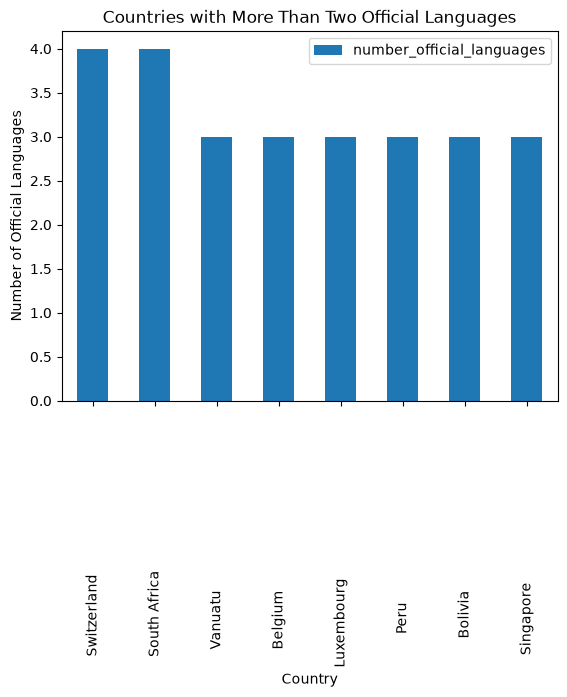

In [ ]:
import matplotlib.pyplot as plt

df.plot(
    x="name",
    y="number_official_languages",
    kind="bar",
)

plt.xlabel("Country")
plt.ylabel("Number of Official Languages")
plt.title("Countries with More Than Two Official Languages")
plt.show()